# Notebook 18 — Slow-rate OCV-like validation audit

## Goal

This notebook audits whether the C/25 OCV-like voltage-curve descriptors established in Notebook 17 remain structurally stable when the diagnostic rate is reduced to C/50.

The purpose is not to introduce a new degradation mechanism, but to test the protocol sensitivity of the OCV-like V(Q), ΔU(Q), ICA, and DVA descriptors.

## Scientific context

Notebook 17 established that C/25 low-rate diagnostic discharge produces smooth OCV-like V(Q) curves across SEI-only aging checkpoints. ICA and DVA were technically extractable after smoothing and quality audit.

The key interpretation boundary of Notebook 17 was:

> C/25 V(Q) is OCV-like or quasi-equilibrium, but not strict thermodynamic OCV.

Notebook 18 directly stress-tests this boundary by comparing C/25 and C/50 diagnostic branches.

## Study design

Aging branch:

- Parameter set: OKane2022
- Aging mechanism: solvent-diffusion-limited SEI only
- Plating: disabled
- LAM: disabled
- particle mechanics: disabled
- SEI porosity change: disabled
- thermal model: isothermal

Checkpoints for the first audit:

- 0 cycles
- 20 cycles

Diagnostic rates:

- C/25
- C/50

Diagnostic protocol:

- start from the pre-diagnostic full-charge-rest aging checkpoint state
- for the 0-cycle reference, use `initial_soc = 1.0`
- discharge at the selected low rate to 2.5 V
- rest for 60 min

## Workflow

1. Rebuild SEI-only 0-cycle and 20-cycle checkpoint states.
2. Run diagnostic-only low-rate discharge branches at C/25 and C/50.
3. Select the final diagnostic discharge segment, avoiding aging-history segments carried by `starting_solution`.
4. Extract V(Q) curves on selected diagnostic segments.
5. Build common-Q comparisons between C/25 and C/50.
6. Audit whether C/25 and C/50 produce structurally consistent V(Q), ΔU(Q), ICA, and DVA features.
7. Classify C/25 adequacy as supported, partially supported, or protocol-sensitive.

## Expected outputs

Data files:

- `data/slow_rate_ocv_validation_segment_audit.csv`
- `data/slow_rate_ocv_validation_selected_segment_audit.csv`
- `data/slow_rate_ocv_validation_curve_table.csv`
- `data/slow_rate_ocv_validation_curve_summary.csv`
- `data/slow_rate_ocv_validation_quality_audit.csv`
- `data/slow_rate_ocv_validation_feature_table.csv`
- `data/slow_rate_ocv_validation_classification_table.csv`

Figures:

- `figures/slow_rate_ocv_validation_VQ_overlay.png`
- `figures/slow_rate_ocv_validation_deltaV_rate_effect.png`
- `figures/slow_rate_ocv_validation_ica_overlay.png`
- `figures/slow_rate_ocv_validation_dva_overlay.png`

## Interpretation boundary

This notebook is a protocol-sensitivity audit.

If C/25 and C/50 produce similar V(Q), ΔU(Q), ICA, and DVA structures, then C/25 can be retained as a practical OCV-like diagnostic rate for this proof-of-concept branch.

If C/50 produces materially different derivative features, then Notebook 17 remains technically valid, but C/25 must be classified as protocol-sensitive rather than quasi-equilibrium stable.

This notebook still does not prove strict thermodynamic OCV unless relaxation effects are separately quantified or a GITT-like protocol is introduced.

In [1]:
# Cell 1 — Imports, paths, and environment check（导入依赖、路径与环境检查）

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pybamm

warnings.filterwarnings("ignore", category=UserWarning)

REPO = Path("/Users/louislu/projects/pybamm-aging-bridge")
DATA = REPO / "data"
FIGURES = REPO / "figures"
DOC_FIGURES = REPO / "docs" / "figures"
DOC_TABLES = REPO / "docs" / "tables"

for p in [DATA, FIGURES, DOC_FIGURES, DOC_TABLES]:
    p.mkdir(parents=True, exist_ok=True)

print("[ENV] PyBaMM:", pybamm.__version__)
print("[ENV] Repository:", REPO)
print("[ENV] Data dir:", DATA)
print("[ENV] Figures dir:", FIGURES)

assert pybamm.__version__ == "26.3.1", "Expected PyBaMM 26.3.1 for this project."
assert REPO.exists(), f"Repository path does not exist: {REPO}"

print("[OK] Environment check passed.")

[ENV] PyBaMM: 26.3.1
[ENV] Repository: /Users/louislu/projects/pybamm-aging-bridge
[ENV] Data dir: /Users/louislu/projects/pybamm-aging-bridge/data
[ENV] Figures dir: /Users/louislu/projects/pybamm-aging-bridge/figures
[OK] Environment check passed.


## Methodological boundary before code execution

Notebook 18 must not be interpreted as a new aging-mechanism branch.

The only variable intentionally changed here is the diagnostic discharge rate:

- C/25 from Notebook 17
- C/50 as a slower validation branch

The aging state, degradation mechanism, checkpoint construction, and segment-selection logic remain aligned with Notebook 17.

The diagnostic branch must not be used to continue aging.

In [2]:
# Cell 2 — SEI-only OKane2022 model builder（SEI-only OKane2022 模型构建函数）

def build_sei_only_model():
    """
    Build DFN model with solvent-diffusion-limited SEI only.
    Other degradation mechanisms are disabled to keep the fingerprint source isolated.
    """
    options = {
        "SEI": "solvent-diffusion limited",
        "SEI porosity change": "false",
        "lithium plating": "none",
        "loss of active material": "none",
        "particle mechanics": "none",
        "thermal": "isothermal",
    }
    model = pybamm.lithium_ion.DFN(options=options)
    parameter_values = pybamm.ParameterValues("OKane2022")
    return model, parameter_values


def make_solver():
    """Create a conservative CasADi solver for degradation-enabled DFN runs."""
    return pybamm.CasadiSolver(
        mode="safe",
        atol=1e-6,
        rtol=1e-6,
        dt_max=600,
    )


model_smoke, pv_smoke = build_sei_only_model()

print("[OK] SEI-only OKane2022 DFN model instantiated.")
print("[MODEL]", model_smoke.name)

[OK] SEI-only OKane2022 DFN model instantiated.
[MODEL] Doyle-Fuller-Newman model


In [3]:
# Cell 3 — Protocol constants and audit design（协议常数与审计设计）

CHECKPOINT_CYCLES = [0, 20]

DIAGNOSTIC_RATES = {
    "C25": {
        "experiment_rate": "C/25",
        "expected_current_A": 0.20,
        "period": "60 seconds",
        "duration_min_lo": 1400,
        "duration_min_hi": 1650,
        "current_lo_A": 0.15,
        "current_hi_A": 0.25,
    },
    "C50": {
        "experiment_rate": "C/50",
        "expected_current_A": 0.10,
        "period": "120 seconds",
        "duration_min_lo": 2800,
        "duration_min_hi": 3300,
        "current_lo_A": 0.075,
        "current_hi_A": 0.125,
    },
}

V_MIN = 2.5

AGING_CYCLE_STEPS = [
    "Discharge at C/3 until 2.5 V",
    "Rest for 10 minutes",
    "Charge at C/3 until 4.2 V",
    "Hold at 4.2 V until C/100",
    "Rest for 10 minutes",
]

print("[CONFIG] checkpoints:", CHECKPOINT_CYCLES)
print("[CONFIG] diagnostic rates:", DIAGNOSTIC_RATES)
print("[CONFIG] V_MIN:", V_MIN)
print("[OK] Protocol constants defined.")

[CONFIG] checkpoints: [0, 20]
[CONFIG] diagnostic rates: {'C25': {'experiment_rate': 'C/25', 'expected_current_A': 0.2, 'period': '60 seconds', 'duration_min_lo': 1400, 'duration_min_hi': 1650, 'current_lo_A': 0.15, 'current_hi_A': 0.25}, 'C50': {'experiment_rate': 'C/50', 'expected_current_A': 0.1, 'period': '120 seconds', 'duration_min_lo': 2800, 'duration_min_hi': 3300, 'current_lo_A': 0.075, 'current_hi_A': 0.125}}
[CONFIG] V_MIN: 2.5
[OK] Protocol constants defined.


In [4]:
# Cell 4 — SEI-only aging checkpoint runner（SEI-only 老化检查点生成函数）

def make_aging_experiment(n_cycles, period="120 seconds"):
    """Build repeated SEI-only aging experiment."""
    if n_cycles == 0:
        return None
    return pybamm.Experiment([tuple(AGING_CYCLE_STEPS)] * n_cycles, period=period)


def run_aging_segment(n_cycles, starting_solution=None, initial_soc=None):
    """
    Run n_cycles of SEI-only aging.

    The returned solution is a pre-diagnostic aging state.
    Diagnostic branches must start from this solution, but must not be used
    to continue aging.
    """
    if n_cycles == 0:
        return starting_solution

    model, pv = build_sei_only_model()
    experiment = make_aging_experiment(n_cycles)
    sim = pybamm.Simulation(
        model,
        parameter_values=pv,
        experiment=experiment,
        solver=make_solver(),
    )

    kwargs = {}
    if starting_solution is not None:
        kwargs["starting_solution"] = starting_solution
    if initial_soc is not None:
        kwargs["initial_soc"] = initial_soc

    sol = sim.solve(**kwargs)
    return sol


checkpoint_solutions = {0: None}

current_solution = None
current_cycle = 0

for target_cycle in CHECKPOINT_CYCLES[1:]:
    n_more = target_cycle - current_cycle
    print(f"[RUN] Aging from cycle {current_cycle} to {target_cycle} ({n_more} cycles)")
    current_solution = run_aging_segment(
        n_cycles=n_more,
        starting_solution=current_solution,
        initial_soc=1.0 if current_cycle == 0 else None,
    )
    checkpoint_solutions[target_cycle] = current_solution
    current_cycle = target_cycle
    print(f"[OK] checkpoint stored: {target_cycle} cycles")

print("[OK] Aging checkpoint generation complete.")
print("[CHECKPOINTS]", sorted(checkpoint_solutions.keys()))

[RUN] Aging from cycle 0 to 20 (20 cycles)
[OK] checkpoint stored: 20 cycles
[OK] Aging checkpoint generation complete.
[CHECKPOINTS] [0, 20]


In [5]:
# Cell 5 — Slow-rate diagnostic branch runner（慢倍率诊断分支运行函数）

def make_slow_rate_experiment(rate_label):
    """Build diagnostic-only slow-rate discharge + rest experiment."""
    cfg = DIAGNOSTIC_RATES[rate_label]
    experiment_rate = cfg["experiment_rate"]

    steps = [
        f"Discharge at {experiment_rate} until {V_MIN} V",
        "Rest for 60 minutes",
    ]

    return pybamm.Experiment(steps, period=cfg["period"])


def run_slow_rate_diagnostic(cycle, rate_label, starting_solution=None):
    """
    Run slow-rate diagnostic branch from a pre-diagnostic aging checkpoint.

    No repeated full-charge preconditioning is applied because the aging checkpoint
    already ends after charge-to-4.2V, CV hold, and 10 min rest.
    """
    model, pv = build_sei_only_model()
    experiment = make_slow_rate_experiment(rate_label)

    sim = pybamm.Simulation(
        model,
        parameter_values=pv,
        experiment=experiment,
        solver=make_solver(),
    )

    kwargs = {}
    if starting_solution is not None:
        kwargs["starting_solution"] = starting_solution
    else:
        kwargs["initial_soc"] = 1.0

    print(f"[RUN] Diagnostic branch: cycle={cycle}, rate={rate_label}")
    sol = sim.solve(**kwargs)
    print(f"[OK] solved: cycle={cycle}, rate={rate_label}")
    return sol


diagnostic_solutions = {}

for cycle in CHECKPOINT_CYCLES:
    for rate_label in DIAGNOSTIC_RATES:
        diagnostic_solutions[(cycle, rate_label)] = run_slow_rate_diagnostic(
            cycle=cycle,
            rate_label=rate_label,
            starting_solution=checkpoint_solutions[cycle],
        )

print("[OK] All slow-rate diagnostic branches solved.")
print("[N solutions]", len(diagnostic_solutions))

[RUN] Diagnostic branch: cycle=0, rate=C25
[OK] solved: cycle=0, rate=C25
[RUN] Diagnostic branch: cycle=0, rate=C50
[OK] solved: cycle=0, rate=C50
[RUN] Diagnostic branch: cycle=20, rate=C25
[OK] solved: cycle=20, rate=C25
[RUN] Diagnostic branch: cycle=20, rate=C50
[OK] solved: cycle=20, rate=C50
[OK] All slow-rate diagnostic branches solved.
[N solutions] 4


In [6]:
# Cell 6 — Selected diagnostic segment audit（选定诊断段审计）

def summarize_current_segments(sol, cycle, rate_label, eps=1e-4):
    """
    Summarize sign-based current segments in a solution.

    PyBaMM sign convention:
    +I = discharge
    -I = charge
    near-zero = rest / near cutoff
    """
    t = np.asarray(sol["Time [s]"].entries, dtype=float)
    v = np.asarray(sol["Terminal voltage [V]"].entries, dtype=float)
    i = np.asarray(sol["Current [A]"].entries, dtype=float)

    state = np.where(i > eps, "discharge", np.where(i < -eps, "charge", "rest"))
    change_idx = np.r_[0, np.flatnonzero(state[1:] != state[:-1]) + 1, len(state)]

    rows = []
    for k in range(len(change_idx) - 1):
        a, b = change_idx[k], change_idx[k + 1]
        if b - a < 2:
            continue

        rows.append({
            "cycle": cycle,
            "rate_label": rate_label,
            "segment_id": k,
            "segment_type": state[a],
            "idx_start": int(a),
            "idx_stop": int(b),
            "t_start_s": float(t[a]),
            "t_end_s": float(t[b - 1]),
            "duration_min": float((t[b - 1] - t[a]) / 60),
            "U_start_V": float(v[a]),
            "U_end_V": float(v[b - 1]),
            "I_mean_A": float(np.mean(i[a:b])),
            "I_min_A": float(np.min(i[a:b])),
            "I_max_A": float(np.max(i[a:b])),
            "n_points": int(b - a),
        })

    return pd.DataFrame(rows)


all_segments = []
selected_segments = []

for (cycle, rate_label), sol in diagnostic_solutions.items():
    cfg = DIAGNOSTIC_RATES[rate_label]
    seg = summarize_current_segments(sol, cycle, rate_label)
    all_segments.append(seg)

    candidates = seg[
        (seg["segment_type"] == "discharge")
        & (seg["I_mean_A"].between(cfg["current_lo_A"], cfg["current_hi_A"]))
        & (seg["duration_min"].between(cfg["duration_min_lo"], cfg["duration_min_hi"]))
    ].copy()

    if candidates.empty:
        raise RuntimeError(f"No valid diagnostic discharge segment found for cycle={cycle}, rate={rate_label}")

    selected = candidates.sort_values("t_start_s").iloc[-1].to_dict()
    selected["selection_rule"] = (
        f"last discharge segment with "
        f"{cfg['current_lo_A']} <= I_mean <= {cfg['current_hi_A']} A "
        f"and {cfg['duration_min_lo']} <= duration <= {cfg['duration_min_hi']} min"
    )
    selected_segments.append(selected)

segment_audit = pd.concat(all_segments, ignore_index=True)
selected_segment_audit = pd.DataFrame(selected_segments)

segment_path = DATA / "slow_rate_ocv_validation_segment_audit.csv"
selected_path = DATA / "slow_rate_ocv_validation_selected_segment_audit.csv"

segment_audit.to_csv(segment_path, index=False)
selected_segment_audit.to_csv(selected_path, index=False)

print(f"[OK] saved: {segment_path}")
print(f"[OK] saved: {selected_path}")

display(selected_segment_audit[[
    "cycle", "rate_label", "segment_id", "duration_min", "U_start_V", "U_end_V",
    "I_mean_A", "n_points", "selection_rule"
]])

print("[OK] Selected diagnostic segments passed rate-specific audit.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/slow_rate_ocv_validation_segment_audit.csv
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/slow_rate_ocv_validation_selected_segment_audit.csv


,cycle,rate_label,segment_id,duration_min,U_start_V,U_end_V,I_mean_A,n_points,selection_rule
0,0,C25,0,1530.187182,4.190343,2.50001,0.2,1532,last discharge segment with 0.15 <= I_mean <= ...
1,0,C50,0,3062.369019,4.195171,2.50001,0.1,1533,last discharge segment with 0.075 <= I_mean <=...
2,20,C25,80,1525.629718,4.184936,2.50001,0.2,1527,last discharge segment with 0.15 <= I_mean <= ...
3,20,C50,80,3053.442082,4.189755,2.50001,0.1,1528,last discharge segment with 0.075 <= I_mean <=...


[OK] Selected diagnostic segments passed rate-specific audit.


In [7]:
# Cell 7 — Selected slow-rate V(Q) curve extraction（选定慢倍率 V(Q) 曲线提取）

def extract_selected_discharge_curve(sol, cycle, rate_label, selected_segment_table):
    """
    Extract the selected diagnostic discharge segment.

    PyBaMM starting_solution carries aging history, so extraction must use the
    selected segment audit rather than the longest discharge segment.
    """
    selected = selected_segment_table[
        (selected_segment_table["cycle"] == cycle)
        & (selected_segment_table["rate_label"] == rate_label)
    ]

    if selected.empty:
        raise RuntimeError(f"No selected segment for cycle={cycle}, rate={rate_label}")

    row = selected.iloc[0]
    a = int(row["idx_start"])
    b = int(row["idx_stop"])

    t = np.asarray(sol["Time [s]"].entries, dtype=float)[a:b]
    v = np.asarray(sol["Terminal voltage [V]"].entries, dtype=float)[a:b]
    i = np.asarray(sol["Current [A]"].entries, dtype=float)[a:b]

    t_rel_s = t - t[0]

    q_Ah = np.zeros_like(t_rel_s)
    if len(t_rel_s) > 1:
        dt_h = np.diff(t_rel_s) / 3600.0
        i_mid = 0.5 * (i[1:] + i[:-1])
        q_Ah[1:] = np.cumsum(i_mid * dt_h)

    q_end_Ah = float(q_Ah[-1])
    nominal_soc = 1.0 - q_Ah / q_end_Ah if q_end_Ah > 0 else np.nan

    out = pd.DataFrame({
        "cycle": cycle,
        "rate_label": rate_label,
        "t_rel_s": t_rel_s,
        "t_rel_h": t_rel_s / 3600.0,
        "Q_dis_Ah": q_Ah,
        "nominal_SOC": nominal_soc,
        "U_V": v,
        "I_A_pybamm": i,
        "segment_id": int(row["segment_id"]),
    })

    return out


curve_tables = []

for (cycle, rate_label), sol in diagnostic_solutions.items():
    df_curve = extract_selected_discharge_curve(
        sol=sol,
        cycle=cycle,
        rate_label=rate_label,
        selected_segment_table=selected_segment_audit,
    )
    curve_tables.append(df_curve)

curve_table = pd.concat(curve_tables, ignore_index=True)

curve_path = DATA / "slow_rate_ocv_validation_curve_table.csv"
curve_table.to_csv(curve_path, index=False)

curve_summary = (
    curve_table
    .groupby(["cycle", "rate_label"], as_index=False)
    .agg(
        n_points=("Q_dis_Ah", "size"),
        Q_end_Ah=("Q_dis_Ah", "max"),
        U_start_V=("U_V", "first"),
        U_end_V=("U_V", "last"),
        I_mean_A=("I_A_pybamm", "mean"),
        t_end_h=("t_rel_h", "max"),
        selected_segment_id=("segment_id", "first"),
    )
)

summary_path = DATA / "slow_rate_ocv_validation_curve_summary.csv"
curve_summary.to_csv(summary_path, index=False)

print(f"[OK] saved: {curve_path}")
print(f"[OK] saved: {summary_path}")
print("[SHAPE]", curve_table.shape)
display(curve_summary)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/slow_rate_ocv_validation_curve_table.csv
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/slow_rate_ocv_validation_curve_summary.csv
[SHAPE] (6120, 9)


,cycle,rate_label,n_points,Q_end_Ah,U_start_V,U_end_V,I_mean_A,t_end_h,selected_segment_id
0,0,C25,1532,5.100624,4.190343,2.50001,0.2,25.503120,0
1,0,C50,1533,5.103948,4.195171,2.50001,0.1,51.039484,0
2,20,C25,1527,5.085432,4.184936,2.50001,0.2,25.427162,80
3,20,C50,1528,5.089070,4.189755,2.50001,0.1,50.890701,80


In [8]:
# Cell 8 — Curve quality and common-Q rate-effect audit（曲线质量与共同 Q 速率效应审计）

quality_rows = []

for (cycle, rate_label), g in curve_table.groupby(["cycle", "rate_label"]):
    g = g.sort_values("Q_dis_Ah").reset_index(drop=True)

    dQ = np.diff(g["Q_dis_Ah"].to_numpy())
    dV = np.diff(g["U_V"].to_numpy())

    n_points = len(g)
    q_end = float(g["Q_dis_Ah"].iloc[-1])
    v_start = float(g["U_V"].iloc[0])
    v_end = float(g["U_V"].iloc[-1])
    voltage_span = v_start - v_end

    q_nonmono = int(np.sum(dQ <= 0))
    v_increase_count = int(np.sum(dV > 1e-5))
    v_increase_fraction = v_increase_count / max(len(dV), 1)

    median_dQ_mAh = float(np.median(dQ) * 1000) if len(dQ) else np.nan
    median_abs_dV_mV = float(np.median(np.abs(dV)) * 1000) if len(dV) else np.nan

    pass_quality = (
        n_points >= 1000
        and q_end > 1.0
        and voltage_span > 1.0
        and q_nonmono == 0
        and v_increase_fraction < 0.01
    )

    quality_rows.append({
        "cycle": cycle,
        "rate_label": rate_label,
        "n_points": n_points,
        "Q_end_Ah": q_end,
        "U_start_V": v_start,
        "U_end_V": v_end,
        "voltage_span_V": voltage_span,
        "Q_nonmonotonic_count": q_nonmono,
        "V_local_increase_count": v_increase_count,
        "V_local_increase_fraction": v_increase_fraction,
        "median_dQ_mAh": median_dQ_mAh,
        "median_abs_dV_mV": median_abs_dV_mV,
        "pass_curve_quality": pass_quality,
    })

quality_audit = pd.DataFrame(quality_rows)

quality_path = DATA / "slow_rate_ocv_validation_quality_audit.csv"
quality_audit.to_csv(quality_path, index=False)

print(f"[OK] saved: {quality_path}")
display(quality_audit)

assert quality_audit["pass_curve_quality"].all(), "At least one curve failed quality audit."

# Common-Q interpolation for C25-vs-C50 comparison
q_common_max = float(curve_summary["Q_end_Ah"].min())
q_grid = np.linspace(0.02, q_common_max - 0.02, 1200)

interp_rows = []

for (cycle, rate_label), g in curve_table.groupby(["cycle", "rate_label"]):
    g = g.sort_values("Q_dis_Ah").reset_index(drop=True)

    q = g["Q_dis_Ah"].to_numpy()
    v = g["U_V"].to_numpy()

    v_interp = np.interp(q_grid, q, v)

    interp_rows.append(pd.DataFrame({
        "cycle": cycle,
        "rate_label": rate_label,
        "Q_dis_Ah": q_grid,
        "U_interp_V": v_interp,
    }))

interp_table = pd.concat(interp_rows, ignore_index=True)

rate_effect_rows = []

for cycle in CHECKPOINT_CYCLES:
    c25 = (
        interp_table[
            (interp_table["cycle"] == cycle)
            & (interp_table["rate_label"] == "C25")
        ]
        .set_index("Q_dis_Ah")["U_interp_V"]
    )

    c50 = (
        interp_table[
            (interp_table["cycle"] == cycle)
            & (interp_table["rate_label"] == "C50")
        ]
        .set_index("Q_dis_Ah")["U_interp_V"]
    )

    delta_mV = (c50 - c25) * 1000

    rate_effect_rows.append({
        "cycle": cycle,
        "Q_common_max_Ah": q_common_max,
        "C50_minus_C25_mean_mV": float(delta_mV.mean()),
        "C50_minus_C25_median_mV": float(delta_mV.median()),
        "C50_minus_C25_max_abs_mV": float(np.max(np.abs(delta_mV))),
        "C50_minus_C25_p95_abs_mV": float(np.percentile(np.abs(delta_mV), 95)),
        "C50_minus_C25_start_mV": float(delta_mV.iloc[0]),
        "C50_minus_C25_end_mV": float(delta_mV.iloc[-1]),
    })

rate_effect_audit = pd.DataFrame(rate_effect_rows)

rate_effect_path = DATA / "slow_rate_ocv_validation_rate_effect_audit.csv"
rate_effect_audit.to_csv(rate_effect_path, index=False)

print(f"[OK] saved: {rate_effect_path}")
display(rate_effect_audit)

print("[OK] Curve quality and common-Q rate-effect audit complete.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/slow_rate_ocv_validation_quality_audit.csv


,cycle,rate_label,n_points,Q_end_Ah,U_start_V,U_end_V,voltage_span_V,Q_nonmonotonic_count,V_local_increase_count,V_local_increase_fraction,median_dQ_mAh,median_abs_dV_mV,pass_curve_quality
0,0,C25,1532,5.100624,4.190343,2.50001,1.690333,0,2,0.001306,3.333333,0.594799,True
1,0,C50,1533,5.103948,4.195171,2.50001,1.695161,0,2,0.001305,3.333333,0.595229,True
2,20,C25,1527,5.085432,4.184936,2.50001,1.684926,0,1,0.000655,3.333333,0.594102,True
3,20,C50,1528,5.089070,4.189755,2.50001,1.689745,0,12,0.007859,3.333333,0.595197,True


[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/slow_rate_ocv_validation_rate_effect_audit.csv


,cycle,Q_common_max_Ah,C50_minus_C25_mean_mV,C50_minus_C25_median_mV,C50_minus_C25_max_abs_mV,C50_minus_C25_p95_abs_mV,C50_minus_C25_start_mV,C50_minus_C25_end_mV
0,0,5.085432,6.14117,5.869861,14.066005,8.507274,8.341716,13.497290
1,20,5.085432,6.21118,5.871900,15.712621,8.511130,8.320188,14.621756


[OK] Curve quality and common-Q rate-effect audit complete.


[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/slow_rate_ocv_validation_feature_table.csv
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/slow_rate_ocv_validation_derivative_table.csv


,cycle,rate_label,Q_common_max_Ah,ICA_peak_mag_Ah_per_V,ICA_peak_Q_Ah,ICA_peak_U_V,DVA_median_mag_V_per_Ah,DVA_peak_mag_V_per_Ah,DVA_peak_Q_Ah,DVA_peak_U_V
0,0,C25,5.085432,22.998392,0.478676,4.087313,0.177562,2.424937,4.977064,2.929657
1,0,C50,5.085432,22.354804,0.524964,4.090194,0.178035,2.393087,4.977064,2.940016
2,20,C25,5.085432,22.449489,0.491300,4.086152,0.177587,2.734796,4.977064,2.890500
3,20,C50,5.085432,23.294933,0.474468,4.092051,0.177662,2.699255,4.977064,2.902157


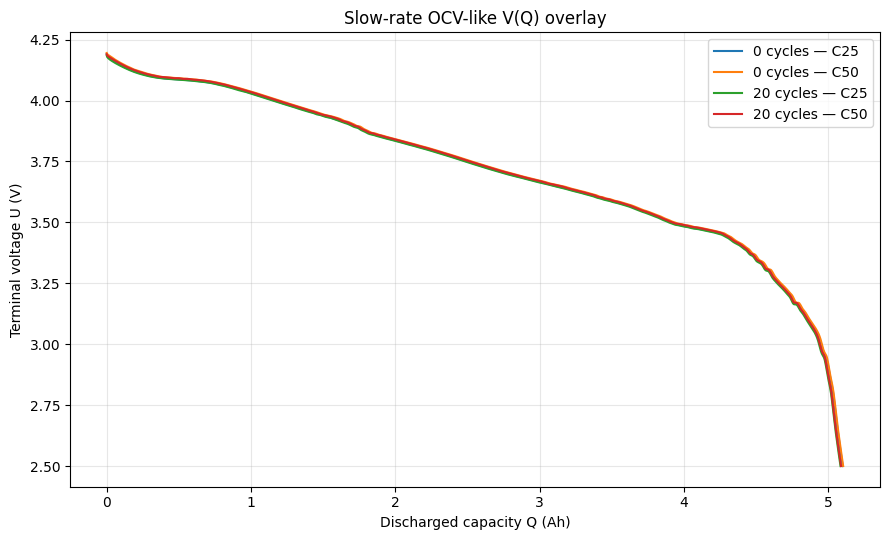

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/slow_rate_ocv_validation_VQ_overlay.png


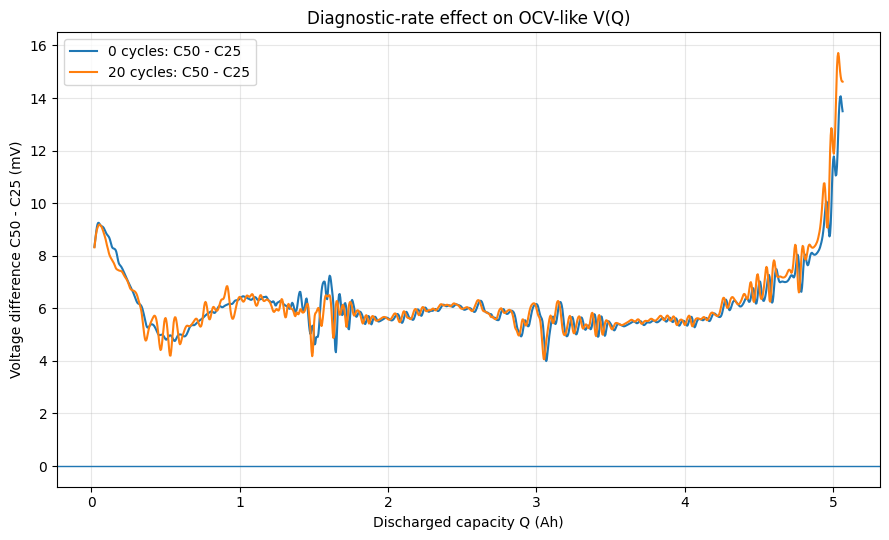

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/slow_rate_ocv_validation_deltaV_rate_effect.png


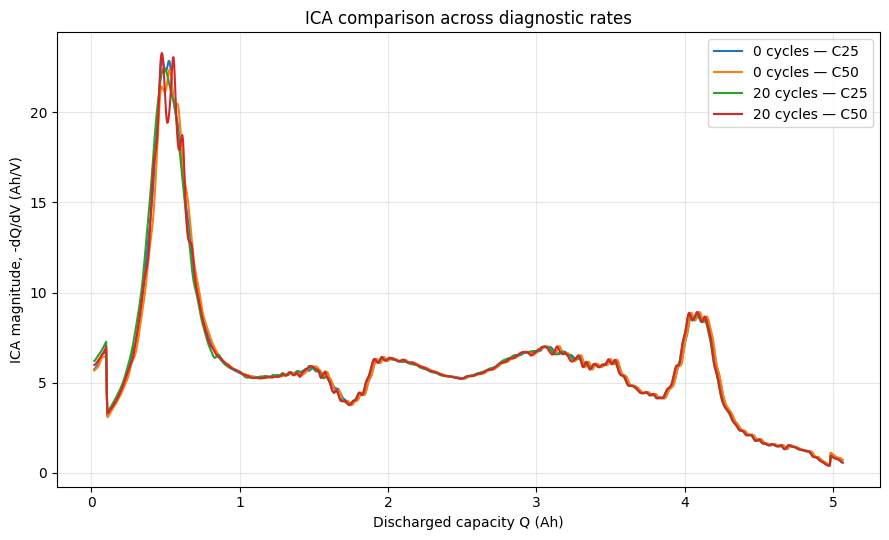

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/slow_rate_ocv_validation_ica_overlay.png


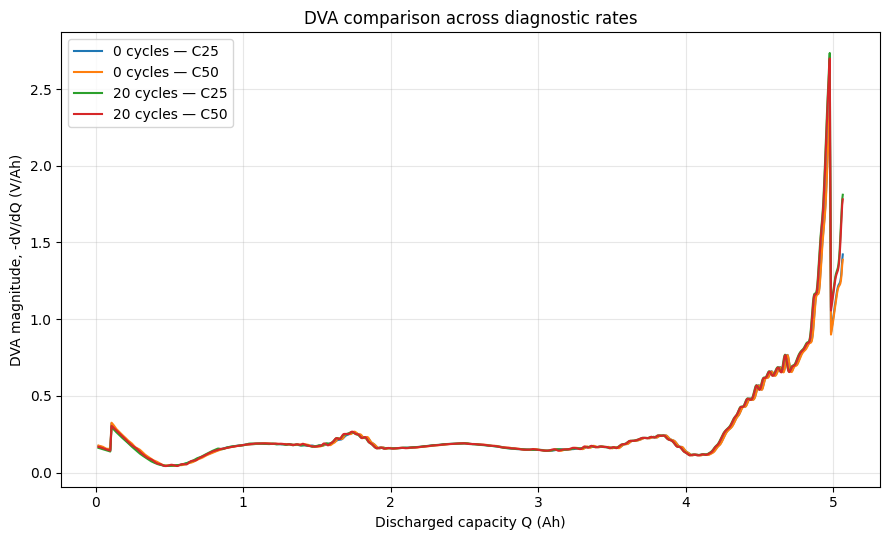

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/slow_rate_ocv_validation_dva_overlay.png


In [9]:
# Cell 9 — V(Q), rate-effect, ICA, and DVA visualization（V(Q)、速率效应与 ICA/DVA 可视化）

def smooth_centered(y, window=41):
    """Simple centered rolling mean smoothing."""
    s = pd.Series(y)
    return s.rolling(window=window, center=True, min_periods=max(3, window // 5)).mean().bfill().ffill().to_numpy()


feature_rows = []
derivative_rows = []

for (cycle, rate_label), g in interp_table.groupby(["cycle", "rate_label"]):
    g = g.sort_values("Q_dis_Ah").reset_index(drop=True)

    q = g["Q_dis_Ah"].to_numpy()
    v = g["U_interp_V"].to_numpy()
    v_smooth = smooth_centered(v, window=41)

    dVdQ = np.gradient(v_smooth, q)

    # discharge curve has dV/dQ < 0; plot positive magnitudes
    dva_mag = -dVdQ
    ica_mag = np.where(np.abs(dVdQ) > 1e-8, -1.0 / dVdQ, np.nan)

    valid = np.isfinite(ica_mag) & np.isfinite(dva_mag)

    i_peak = np.nanargmax(np.where(valid, ica_mag, np.nan))
    d_peak = np.nanargmax(np.where(valid, dva_mag, np.nan))

    feature_rows.append({
        "cycle": cycle,
        "rate_label": rate_label,
        "Q_common_max_Ah": q_common_max,
        "ICA_peak_mag_Ah_per_V": float(ica_mag[i_peak]),
        "ICA_peak_Q_Ah": float(q[i_peak]),
        "ICA_peak_U_V": float(v_smooth[i_peak]),
        "DVA_median_mag_V_per_Ah": float(np.nanmedian(dva_mag[valid])),
        "DVA_peak_mag_V_per_Ah": float(dva_mag[d_peak]),
        "DVA_peak_Q_Ah": float(q[d_peak]),
        "DVA_peak_U_V": float(v_smooth[d_peak]),
    })

    derivative_rows.append(pd.DataFrame({
        "cycle": cycle,
        "rate_label": rate_label,
        "Q_dis_Ah": q,
        "U_smooth_V": v_smooth,
        "ICA_discharge_mag_Ah_per_V": ica_mag,
        "DVA_discharge_mag_V_per_Ah": dva_mag,
    }))

feature_table = pd.DataFrame(feature_rows)
derivative_table = pd.concat(derivative_rows, ignore_index=True)

feature_path = DATA / "slow_rate_ocv_validation_feature_table.csv"
derivative_path = DATA / "slow_rate_ocv_validation_derivative_table.csv"

feature_table.to_csv(feature_path, index=False)
derivative_table.to_csv(derivative_path, index=False)

print(f"[OK] saved: {feature_path}")
print(f"[OK] saved: {derivative_path}")
display(feature_table)

# Figure 1: V(Q) overlay
plt.figure(figsize=(9, 5.5))
for (cycle, rate_label), g in curve_table.groupby(["cycle", "rate_label"]):
    plt.plot(g["Q_dis_Ah"], g["U_V"], label=f"{cycle} cycles — {rate_label}")
plt.xlabel("Discharged capacity Q (Ah)")
plt.ylabel("Terminal voltage U (V)")
plt.title("Slow-rate OCV-like V(Q) overlay")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
p = FIGURES / "slow_rate_ocv_validation_VQ_overlay.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")

# Figure 2: C50 - C25 rate effect
plt.figure(figsize=(9, 5.5))
for cycle in CHECKPOINT_CYCLES:
    c25 = (
        interp_table[
            (interp_table["cycle"] == cycle)
            & (interp_table["rate_label"] == "C25")
        ]
        .set_index("Q_dis_Ah")["U_interp_V"]
    )
    c50 = (
        interp_table[
            (interp_table["cycle"] == cycle)
            & (interp_table["rate_label"] == "C50")
        ]
        .set_index("Q_dis_Ah")["U_interp_V"]
    )
    delta_mV = (c50 - c25) * 1000
    plt.plot(q_grid, delta_mV, label=f"{cycle} cycles: C50 - C25")
plt.axhline(0, linewidth=1)
plt.xlabel("Discharged capacity Q (Ah)")
plt.ylabel("Voltage difference C50 - C25 (mV)")
plt.title("Diagnostic-rate effect on OCV-like V(Q)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
p = FIGURES / "slow_rate_ocv_validation_deltaV_rate_effect.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")

# Figure 3: ICA overlay
plt.figure(figsize=(9, 5.5))
for (cycle, rate_label), g in derivative_table.groupby(["cycle", "rate_label"]):
    plt.plot(g["Q_dis_Ah"], g["ICA_discharge_mag_Ah_per_V"], label=f"{cycle} cycles — {rate_label}")
plt.xlabel("Discharged capacity Q (Ah)")
plt.ylabel("ICA magnitude, -dQ/dV (Ah/V)")
plt.title("ICA comparison across diagnostic rates")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
p = FIGURES / "slow_rate_ocv_validation_ica_overlay.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")

# Figure 4: DVA overlay
plt.figure(figsize=(9, 5.5))
for (cycle, rate_label), g in derivative_table.groupby(["cycle", "rate_label"]):
    plt.plot(g["Q_dis_Ah"], g["DVA_discharge_mag_V_per_Ah"], label=f"{cycle} cycles — {rate_label}")
plt.xlabel("Discharged capacity Q (Ah)")
plt.ylabel("DVA magnitude, -dV/dQ (V/Ah)")
plt.title("DVA comparison across diagnostic rates")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
p = FIGURES / "slow_rate_ocv_validation_dva_overlay.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")

In [10]:
# Cell 10 — Slow-rate validation classification（慢倍率验证分类）

# Build derivative feature rate-difference table
feature_rate_rows = []

for cycle in CHECKPOINT_CYCLES:
    f25 = feature_table[
        (feature_table["cycle"] == cycle)
        & (feature_table["rate_label"] == "C25")
    ].iloc[0]

    f50 = feature_table[
        (feature_table["cycle"] == cycle)
        & (feature_table["rate_label"] == "C50")
    ].iloc[0]

    feature_rate_rows.append({
        "cycle": cycle,
        "ICA_peak_Q_shift_C50_minus_C25_Ah": float(f50["ICA_peak_Q_Ah"] - f25["ICA_peak_Q_Ah"]),
        "ICA_peak_mag_rel_change_C50_vs_C25_pct": float(
            (f50["ICA_peak_mag_Ah_per_V"] - f25["ICA_peak_mag_Ah_per_V"])
            / f25["ICA_peak_mag_Ah_per_V"] * 100
        ),
        "DVA_median_rel_change_C50_vs_C25_pct": float(
            (f50["DVA_median_mag_V_per_Ah"] - f25["DVA_median_mag_V_per_Ah"])
            / f25["DVA_median_mag_V_per_Ah"] * 100
        ),
        "DVA_peak_rel_change_C50_vs_C25_pct": float(
            (f50["DVA_peak_mag_V_per_Ah"] - f25["DVA_peak_mag_V_per_Ah"])
            / f25["DVA_peak_mag_V_per_Ah"] * 100
        ),
    })

feature_rate_audit = pd.DataFrame(feature_rate_rows)

feature_rate_path = DATA / "slow_rate_ocv_validation_feature_rate_audit.csv"
feature_rate_audit.to_csv(feature_rate_path, index=False)

print(f"[OK] saved: {feature_rate_path}")
display(feature_rate_audit)

max_rate_p95_mV = float(rate_effect_audit["C50_minus_C25_p95_abs_mV"].max())
max_rate_abs_mV = float(rate_effect_audit["C50_minus_C25_max_abs_mV"].max())
max_ica_q_shift = float(np.max(np.abs(feature_rate_audit["ICA_peak_Q_shift_C50_minus_C25_Ah"])))
max_ica_mag_rel = float(np.max(np.abs(feature_rate_audit["ICA_peak_mag_rel_change_C50_vs_C25_pct"])))
max_dva_median_rel = float(np.max(np.abs(feature_rate_audit["DVA_median_rel_change_C50_vs_C25_pct"])))

# Conservative classification logic
if (
    max_rate_p95_mV <= 10
    and max_ica_q_shift <= 0.03
    and max_ica_mag_rel <= 10
    and max_dva_median_rel <= 10
):
    verdict = "C25 adequate for practical OCV-like feasibility branch"
    strength = "supported"
elif (
    max_rate_p95_mV <= 20
    and max_ica_q_shift <= 0.05
    and max_ica_mag_rel <= 20
    and max_dva_median_rel <= 20
):
    verdict = "C25 partially supported; derivative features remain protocol-sensitive"
    strength = "partially supported"
else:
    verdict = "C25 protocol-sensitive; slower diagnostic branch recommended"
    strength = "protocol-sensitive"

classification_rows = [
    {
        "metric_layer": "segment_quality",
        "evidence": "All C25 and C50 selected diagnostic discharge segments passed current and duration audit.",
        "strength": "strong",
        "classification": "rate-comparison diagnostic segments are valid",
    },
    {
        "metric_layer": "curve_quality",
        "evidence": f"All curves passed V(Q) quality audit = {bool(quality_audit['pass_curve_quality'].all())}",
        "strength": "strong",
        "classification": "C25 and C50 V(Q) curves are technically comparable",
    },
    {
        "metric_layer": "VQ_rate_effect",
        "evidence": f"max p95 |C50-C25| = {max_rate_p95_mV:.3f} mV; max absolute |C50-C25| = {max_rate_abs_mV:.3f} mV",
        "strength": "data-backed",
        "classification": "diagnostic-rate voltage effect quantified on common Q-grid",
    },
    {
        "metric_layer": "ICA_rate_effect",
        "evidence": f"max ICA peak Q shift = {max_ica_q_shift:.4f} Ah; max ICA peak magnitude relative change = {max_ica_mag_rel:.3f} %",
        "strength": "audit-level",
        "classification": "ICA rate sensitivity quantified",
    },
    {
        "metric_layer": "DVA_rate_effect",
        "evidence": f"max DVA median relative change = {max_dva_median_rel:.3f} %",
        "strength": "audit-level",
        "classification": "DVA central-shape rate sensitivity quantified; endpoint peak remains conservative",
    },
    {
        "metric_layer": "overall",
        "evidence": "C25 and C50 slow-rate diagnostic outputs were compared at 0 and 20 cycles.",
        "strength": strength,
        "classification": verdict,
    },
]

classification_table = pd.DataFrame(classification_rows)

classification_path = DATA / "slow_rate_ocv_validation_classification_table.csv"
classification_table.to_csv(classification_path, index=False)

print(f"[OK] saved: {classification_path}")
display(classification_table)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/slow_rate_ocv_validation_feature_rate_audit.csv


,cycle,ICA_peak_Q_shift_C50_minus_C25_Ah,ICA_peak_mag_rel_change_C50_vs_C25_pct,DVA_median_rel_change_C50_vs_C25_pct,DVA_peak_rel_change_C50_vs_C25_pct
0,0,0.046288,-2.798405,0.266356,-1.313450
1,20,-0.016832,3.765982,0.042356,-1.299585


[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/slow_rate_ocv_validation_classification_table.csv


,metric_layer,evidence,strength,classification
0,segment_quality,All C25 and C50 selected diagnostic discharge ...,strong,rate-comparison diagnostic segments are valid
1,curve_quality,All curves passed V(Q) quality audit = True,strong,C25 and C50 V(Q) curves are technically compar...
2,VQ_rate_effect,max p95 |C50-C25| = 8.511 mV; max absolute |C5...,data-backed,diagnostic-rate voltage effect quantified on c...
3,ICA_rate_effect,max ICA peak Q shift = 0.0463 Ah; max ICA peak...,audit-level,ICA rate sensitivity quantified
4,DVA_rate_effect,max DVA median relative change = 0.266 %,audit-level,DVA central-shape rate sensitivity quantified;...
5,overall,C25 and C50 slow-rate diagnostic outputs were ...,partially supported,C25 partially supported; derivative features r...


In [11]:
# Cell 11 — Output inventory audit（输出文件清单审计）

expected_outputs = [
    DATA / "slow_rate_ocv_validation_segment_audit.csv",
    DATA / "slow_rate_ocv_validation_selected_segment_audit.csv",
    DATA / "slow_rate_ocv_validation_curve_table.csv",
    DATA / "slow_rate_ocv_validation_curve_summary.csv",
    DATA / "slow_rate_ocv_validation_quality_audit.csv",
    DATA / "slow_rate_ocv_validation_rate_effect_audit.csv",
    DATA / "slow_rate_ocv_validation_feature_table.csv",
    DATA / "slow_rate_ocv_validation_derivative_table.csv",
    DATA / "slow_rate_ocv_validation_feature_rate_audit.csv",
    DATA / "slow_rate_ocv_validation_classification_table.csv",
    FIGURES / "slow_rate_ocv_validation_VQ_overlay.png",
    FIGURES / "slow_rate_ocv_validation_deltaV_rate_effect.png",
    FIGURES / "slow_rate_ocv_validation_ica_overlay.png",
    FIGURES / "slow_rate_ocv_validation_dva_overlay.png",
]

inventory_rows = []

for p in expected_outputs:
    inventory_rows.append({
        "path": str(p.relative_to(REPO)),
        "exists": p.exists(),
        "size_kB": round(p.stat().st_size / 1024, 2) if p.exists() else np.nan,
    })

output_inventory = pd.DataFrame(inventory_rows)

inventory_path = DATA / "slow_rate_ocv_validation_output_inventory.csv"
output_inventory.to_csv(inventory_path, index=False)

print(f"[OK] saved: {inventory_path}")
display(output_inventory)

assert output_inventory["exists"].all(), "Some expected output files are missing."
print("[OK] All expected Notebook 18 outputs exist.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/slow_rate_ocv_validation_output_inventory.csv


,path,exists,size_kB
0,data/slow_rate_ocv_validation_segment_audit.csv,True,25.49
1,data/slow_rate_ocv_validation_selected_segment...,True,1.19
2,data/slow_rate_ocv_validation_curve_table.csv,True,685.58
3,data/slow_rate_ocv_validation_curve_summary.csv,True,0.51
4,data/slow_rate_ocv_validation_quality_audit.csv,True,0.79
5,data/slow_rate_ocv_validation_rate_effect_audi...,True,0.41
6,data/slow_rate_ocv_validation_feature_table.csv,True,0.76
7,data/slow_rate_ocv_validation_derivative_table...,True,381.09
8,data/slow_rate_ocv_validation_feature_rate_aud...,True,0.31
9,data/slow_rate_ocv_validation_classification_t...,True,0.92


[OK] All expected Notebook 18 outputs exist.


## Final closure — Notebook 18

### Key findings

Notebook 18 audited the diagnostic-rate sensitivity of the OCV-like voltage-curve descriptors established in Notebook 17.

The audit compared C/25 and C/50 diagnostic discharge branches at two SEI-only aging checkpoints:

- 0 cycles
- 20 cycles

The aging mechanism, model configuration, checkpoint construction, and diagnostic-segment selection logic were kept aligned with Notebook 17. The only intentional change was the diagnostic discharge rate.

The selected diagnostic segments passed the rate-specific segment audit. The C/25 branches showed:

- mean current ≈ 0.2 A,
- duration ≈ 1525–1530 min,
- Q_end ≈ 5.085–5.101 Ah.

The C/50 branches showed:

- mean current ≈ 0.1 A,
- duration ≈ 3053–3062 min,
- Q_end ≈ 5.089–5.104 Ah.

All V(Q) curves passed the quality audit. Q was monotonic, each curve contained more than 1500 points, and the local voltage-increase fraction remained below the quality threshold.

The common-Q rate-effect audit showed that C/50 produces a systematically higher terminal voltage than C/25, as expected from reduced ohmic and polarization losses. The mean C50–C25 voltage offset was approximately +6.1 to +6.2 mV. The p95 absolute voltage difference was approximately 8.51 mV, while the maximum absolute difference reached approximately 14–16 mV near the low-voltage endpoint.

This indicates that the main V(Q) structure is broadly stable between C/25 and C/50, while endpoint regions remain rate-sensitive.

ICA features were technically extractable at both rates. The dominant ICA peak remains present, but its peak position shows non-negligible rate sensitivity:

- 0 cycles: C50–C25 ICA peak-Q shift ≈ +0.0463 Ah,
- 20 cycles: C50–C25 ICA peak-Q shift ≈ −0.0168 Ah.

The ICA peak magnitude changed by approximately −2.80% at 0 cycles and +3.77% at 20 cycles. Therefore, the existence and approximate shape of the ICA peak are stable, but ICA peak position should not be interpreted as strictly rate-invariant.

DVA features were also technically extractable. The DVA median magnitude was highly stable between C/25 and C/50, with relative changes below 0.3%. The DVA endpoint peak changed by approximately −1.3%. This suggests that the central DVA shape is comparatively rate-stable, while endpoint-region interpretation remains conservative.

### Interpretation boundary

Notebook 18 supports the practical use of C/25 as an OCV-like feasibility diagnostic branch, but only with a qualified interpretation.

The C/25 branch is adequate for extracting smooth V(Q), ΔU(Q), ICA, and DVA descriptors at the audit level. However, comparison with C/50 shows that derivative features are not fully protocol-invariant. In particular, ICA peak position remains sensitive to diagnostic rate and should not be overinterpreted as a strict thermodynamic OCV feature.

The result therefore strengthens, rather than removes, the boundary established in Notebook 17:

> C/25 is useful as a practical OCV-like diagnostic rate, but it is not equivalent to strict thermodynamic OCV.

### Correct conclusion wording

Supported:

- C/25 and C/50 selected diagnostic segments are technically valid.
- C/25 and C/50 V(Q) curves are smooth, monotonic, and comparable on a common-Q grid.
- C/50 produces a systematic voltage elevation relative to C/25, consistent with lower polarization at lower current.
- The main V(Q) structure remains broadly stable between C/25 and C/50.
- ICA and DVA features are extractable at both rates.
- DVA central-shape descriptors are comparatively rate-stable.

Partially supported:

- C/25 can be retained as a practical OCV-like feasibility branch.
- ICA peak structure is visible at both rates, but peak position is protocol-sensitive.

Not supported:

- C/25 is not proven to be strict thermodynamic OCV.
- ICA peak position is not rate-invariant.
- Endpoint-region DVA peaks should not be interpreted without caution.
- This notebook does not establish mechanism-unique SEI fingerprints.

### Classification

`C/25 OCV-like diagnostic branch = partially supported`

The appropriate project-level classification is:

> C/25 is adequate for practical OCV-like feasibility analysis, but derivative-level interpretation remains protocol-sensitive.

### Next step

The next possible extension is not to repeat the same C/25–C/50 comparison at all intermediate checkpoints unless needed.

More informative next branches are:

1. GITT-like OCV reconstruction, to test whether relaxation-based quasi-equilibrium reconstruction changes the voltage-curve interpretation;
2. stronger aging checkpoints, to determine whether ICA/DVA drift becomes more separable at higher degradation severity;
3. plating or LAM mechanism branches, to test whether derivative features become mechanism-discriminative under stronger and more specific degradation modes.